<a href="https://colab.research.google.com/github/SreeLekha-27/DA-Python-Module-End-Assignment/blob/main/Social_Media_Engagement_Analytics_Using_Python_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Data Import & Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df=pd.read_csv("https://raw.githubusercontent.com/SreeLekha-27/Datasets/refs/heads/main/social_media_engagement_5000.csv")
df.head(1)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df['posted_at']=pd.to_datetime(df['posted_at'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
# Data Cleaning
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Cleaning Missing Data
df["age"].fillna(df["age"].median(),inplace=True)

In [ ]:
df["likes"].fillna(df["likes"].median(),inplace=True)

In [ ]:
df["comments"].fillna(df["comments"].median(),inplace=True)

In [ ]:
df["shares"].fillna(df["shares"].median(),inplace=True)

In [ ]:
df["gender"].fillna(df["gender"].mode()[0],inplace=True)

In [ ]:
df["sentiment"].fillna(df["sentiment"].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
# Duplicate Handling
df.duplicated().sum()

np.int64(0)

In [ ]:
# Data Formatting
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [ ]:
df['post_type'].unique()

array(['image', 'reel', 'text', 'video'], dtype=object)

In [ ]:
df['post_category'].unique()

array(['fitness', 'food', 'tech', 'travel', 'fashion', 'lifestyle',
       'education', 'music'], dtype=object)

In [ ]:
df['device_type'].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [ ]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [ ]:
cols = ['post_type', 'post_category', 'device_type', 'sentiment']

df[cols] = df[cols].apply(lambda x: x.str.capitalize())

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,Reel,Food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,Text,Food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,Text,Fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,Image,Fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372


In [ ]:
# Feature Cleaning
df['hashtags']

,hashtags
0,#foodie #travel #love
1,#fitness
2,#foodie
3,#music #foodie #fun
4,#travel
...,...
4995,#travel #fun
4996,#foodie #reels
4997,#lifestyle #tech
4998,#reels #love #fitness


In [ ]:
df['hashtag_count'] = df['hashtags'].apply(
    lambda x: len(x.split())
)

In [ ]:
df[['hashtags','hashtag_count']]

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
...,...,...
4995,#travel #fun,2
4996,#foodie #reels,2
4997,#lifestyle #tech,2
4998,#reels #love #fitness,3


In [ ]:
# Data Exploration using Pandas
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,Reel,Food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,Text,Food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,Text,Fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,Image,Fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,1


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,Video,Education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,Reel,Education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,Text,Travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,Video,Fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,Text,Travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,Desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,1849
Other,1581
Female,1570


In [ ]:
df['post_type'].unique()

array(['Image', 'Reel', 'Text', 'Video'], dtype=object)

In [ ]:
df['post_category'].nunique()

8

In [4]:
df.select_dtypes(include='number').corr()


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
user_id,1.000000,-0.006789,0.020051,0.026228,-0.033874,0.014004,-0.016847,0.015326,0.010124,-0.004282
age,-0.006789,1.000000,-0.013353,-0.037371,-0.007491,0.014348,0.005677,0.013513,-0.025416,0.008044
post_id,0.020051,-0.013353,1.000000,0.014773,-0.010724,0.001901,0.018374,-0.007709,-0.002844,0.010139
likes,0.026228,-0.037371,0.014773,1.000000,-0.018980,0.004799,0.008837,0.008067,-0.023331,0.093555
comments,-0.033874,-0.007491,-0.010724,-0.018980,1.000000,0.006310,-0.016616,-0.009537,-0.011921,0.000046
shares,0.014004,0.014348,0.001901,0.004799,0.006310,1.000000,0.014898,-0.005178,-0.010891,0.021804
watch_time_sec,-0.016847,0.005677,0.018374,0.008837,-0.016616,0.014898,1.000000,-0.004335,0.002761,-0.001148
impression_count,0.015326,0.013513,-0.007709,0.008067,-0.009537,-0.005178,-0.004335,1.000000,-0.015513,-0.232226
follower_count,0.010124,-0.025416,-0.002844,-0.023331,-0.011921,-0.010891,0.002761,-0.015513,1.000000,0.002292
engagement_rate,-0.004282,0.008044,0.010139,0.093555,0.000046,0.021804,-0.001148,-0.232226,0.002292,1.000000


In [ ]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
Image,10104.865277
Reel,10037.802416
Text,10100.148193
Video,10188.600000


In [ ]:
df.groupby('country')['impression_count'].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [ ]:
df.groupby('sentiment')['engagement_rate'].mean()

,engagement_rate
sentiment,
Negative,1.038486
Neutral,0.991170
Positive,0.919744


In [ ]:
# Data Wrangling
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

In [ ]:
df[['likes', 'comments', 'shares', 'engagement_score']].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [ ]:
df[[ 'age', 'likes', 'comments', 'shares',
    'watch_time_sec', 'impression_count',
    'follower_count', 'engagement_rate']].skew()

,0
age,0.023713
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
impression_count,0.015232
follower_count,0.041118
engagement_rate,18.781271


In [ ]:
df['engagement_rate'].describe()


,engagement_rate
count,5000.000000
mean,0.964356
std,5.318029
min,0.006363
25%,0.145781
50%,0.253896
75%,0.504794
max,191.504348


In [ ]:
df['log_engagement_rate'] = np.log1p(df['engagement_rate'])

In [ ]:
df[['engagement_rate', 'log_engagement_rate']].head(10)

,engagement_rate,log_engagement_rate
0,0.190862,0.174678
1,0.201493,0.183565
2,0.137345,0.128696
3,0.106195,0.100927
4,2.777372,1.329028
5,0.579440,0.457070
6,0.160329,0.148703
7,0.148745,0.138670
8,0.533914,0.427823
9,0.200507,0.182744


In [ ]:
df[['engagement_rate', 'log_engagement_rate']].skew()

,0
engagement_rate,18.781271
log_engagement_rate,4.091482


In [ ]:
df.groupby('post_type')[['likes', 'comments', 'shares', 'engagement_score']].mean()

,likes,comments,shares,engagement_score
post_type,,,,
Image,10104.865277,1525.235766,1019.289495,12649.390537
Reel,10037.802416,1504.187062,982.042089,12524.031567
Text,10100.148193,1499.106024,1013.989558,12613.243775
Video,10188.600000,1479.160000,996.834286,12664.594286


In [ ]:
df.groupby('country')[['impression_count', 'engagement_score']].mean()

,impression_count,engagement_score
country,,
Australia,48346.383367,12809.621704
Brazil,49193.174603,12385.983135
Canada,48703.150097,12605.894737
France,51727.673387,12903.384073
Germany,48605.406122,12635.664286
India,52462.386916,12492.701869
Japan,49616.135593,12578.648305
UAE,48928.413519,12757.777336
UK,51119.393509,12384.374239


In [ ]:
df.groupby('sentiment')[['likes', 'engagement_rate', 'engagement_score']].mean()

,likes,engagement_rate,engagement_score
sentiment,,,
Negative,10208.096875,1.038486,12731.498958
Neutral,9923.194499,0.991170,12448.163720
Positive,10180.062077,0.919744,12665.799443


In [ ]:
# Statistical Analysis
cols = [
    'likes', 'comments', 'shares',
    'watch_time_sec', 'engagement_rate', 'follower_count'
]

# Mean
df[cols].mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
# Median
df[cols].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
# Mode
df[cols].mode()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,10105.5,1497.0,1012.0,916.0,0.006363,497502.0
1,NaN,NaN,NaN,2145.0,0.007420,NaN
2,NaN,NaN,NaN,4360.0,0.012676,NaN
3,NaN,NaN,NaN,7003.0,0.012692,NaN
4,NaN,NaN,NaN,7688.0,0.015005,NaN
...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,87.266094,NaN
4996,NaN,NaN,NaN,NaN,92.828829,NaN
4997,NaN,NaN,NaN,NaN,105.752212,NaN
4998,NaN,NaN,NaN,NaN,121.931973,NaN


In [ ]:
# Standard deviation
df[cols].std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [ ]:
# Variance
df[cols].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [ ]:
# Percentiles
df[cols].quantile([0.25, 0.5, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [ ]:
# Skewness
df[cols].skew()


,0
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [ ]:
# Kurtosis
df[cols].kurt()


,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


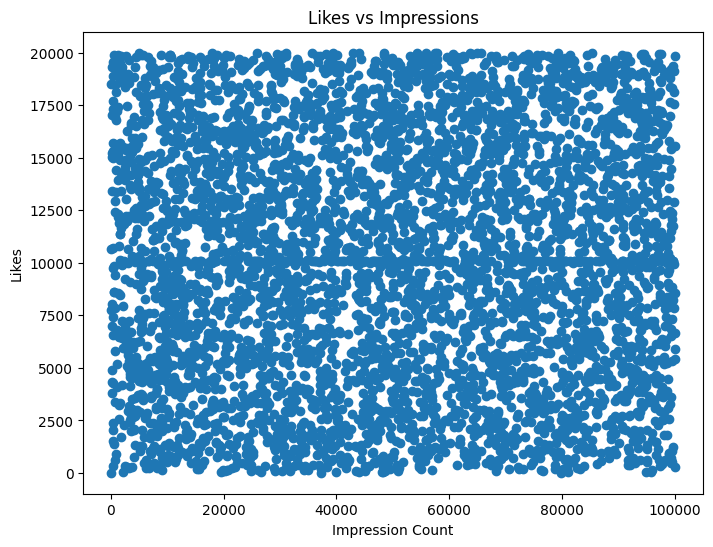

In [ ]:
# Scatter: Likes vs Impressions
plt.figure(figsize=(8,6))
plt.scatter(df['impression_count'], df['likes'])
plt.title("Likes vs Impressions")
plt.xlabel("Impression Count")
plt.ylabel("Likes")
plt.show()

**Insights**

The scatter plot reveals no clear correlation between Impressions and Likes, as the data points are uniformly distributed across the entire range.

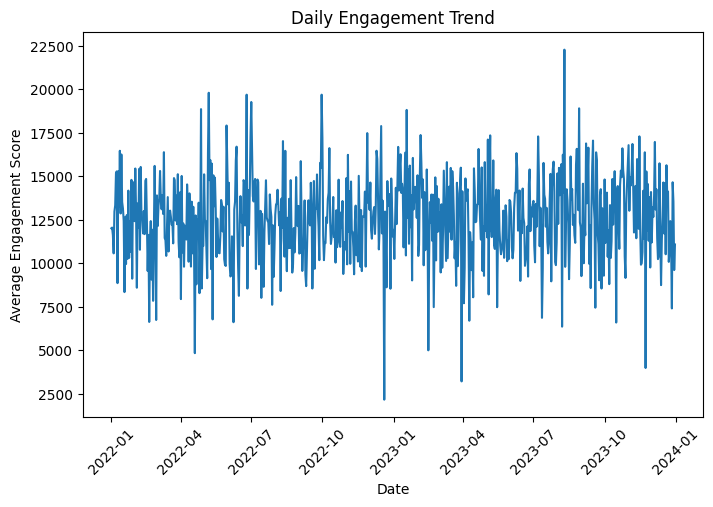

In [ ]:
# Plot line chart
df['posted_at'] = pd.to_datetime(df['posted_at'])
df['date'] = df['posted_at'].dt.date
daily_engagement = df.groupby('date')['engagement_score'].mean()

plt.figure(figsize=(8,5))
plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel('Date')
plt.ylabel('Average Engagement Score')
plt.title('Daily Engagement Trend')
plt.xticks(rotation=45)
plt.show()


**Insight**

The line chart shows that engagement is not consistent every day. Some days have noticeably higher average engagement scores, indicating peak activity periods when users interact more with content.

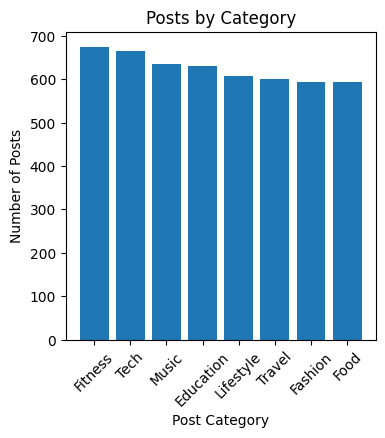

In [ ]:
# Bar: posts by category
post_cat_counts = df['post_category'].value_counts()

plt.figure(figsize=(4,4))
plt.bar(post_cat_counts.index, post_cat_counts.values)
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')
plt.xticks(rotation=45)
plt.show()


**Insight**

The bar chart shows how content is distributed across different post categories. Some categories have significantly more posts, indicating that creators focus more on these content types. Categories with fewer posts may represent niche content or areas with less posting frequency.

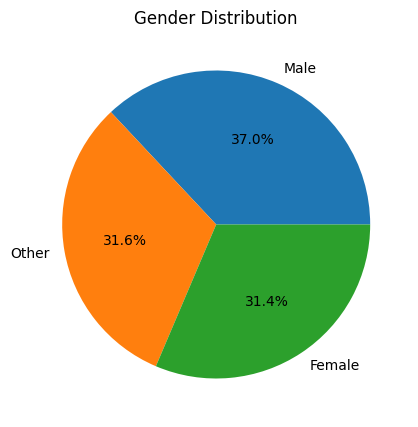

In [ ]:
# Pie: gender distribution
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()


**Insight**

The pie chart shows the overall gender split of users in the dataset. One gender has a slightly higher share compared to others, indicating a dominant user group on the platform. This distribution is useful for understanding the audience base and helps in analyzing engagement patterns across different genders.

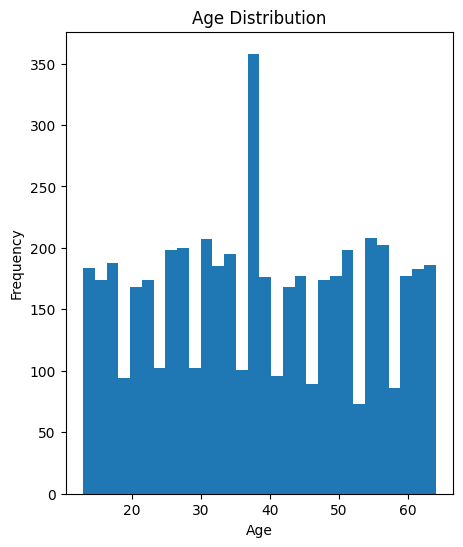

In [ ]:
# Histogram: age
plt.figure(figsize=(5,6))
plt.hist(df['age'], bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()


**Insight**

The histogram shows that the majority of users fall within a mid-age range, while very young and older age groups appear less frequently. This indicates that the platform is mainly used by young to middle-aged users, which helps explain engagement patterns seen in the analysis.

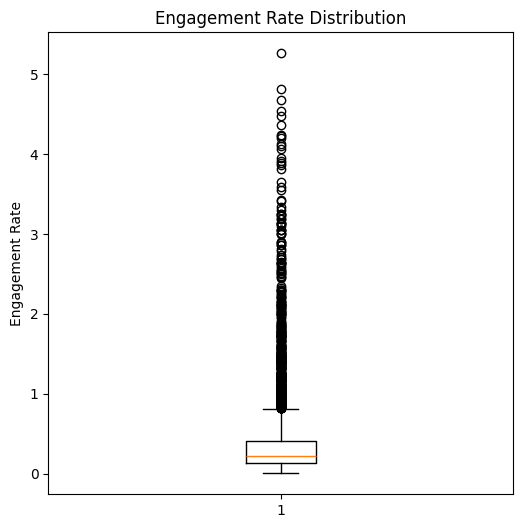

In [ ]:
# Box: engagement rate
plt.figure(figsize=(6,6))
plt.boxplot(df['log_engagement_rate'])
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')
plt.show()

**Insight**

The box plot shows that engagement rates vary widely across posts. The presence of outliers indicates that a few posts perform exceptionally well compared to the rest. Since the engagement rate is log-transformed, the impact of extreme values is reduced, making the overall distribution easier to analyze without affecting the main trend.

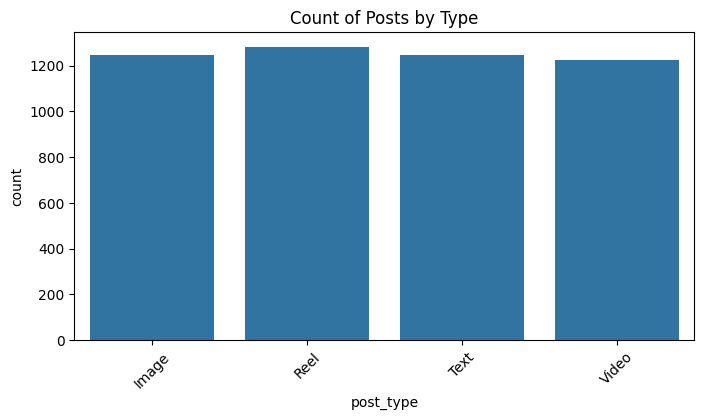

In [ ]:
# Seaborn
# Count plot: post type
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='post_type')
plt.title("Count of Posts by Type")
plt.xticks(rotation=45)
plt.show()


**Insight**

Some post types are clearly posted more often, showing which formats creators prefer the most.

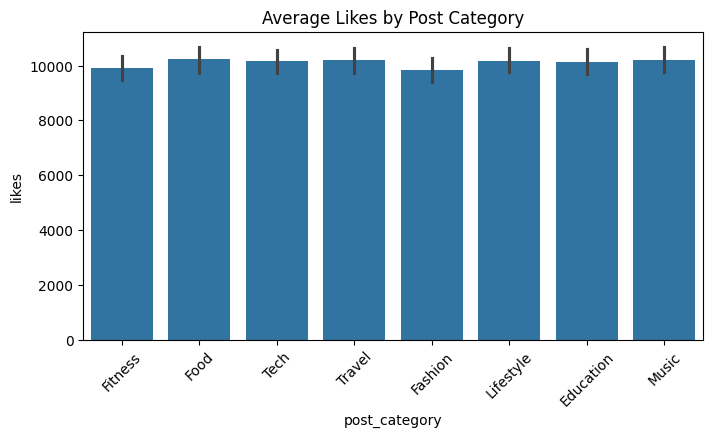

In [ ]:
# Bar plot: avg likes by category
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='post_category', y='likes', estimator='mean')
plt.title("Average Likes by Post Category")
plt.xticks(rotation=45)
plt.show()

**Insight**

Certain categories get more likes on average, showing what kind of content users enjoy the most.

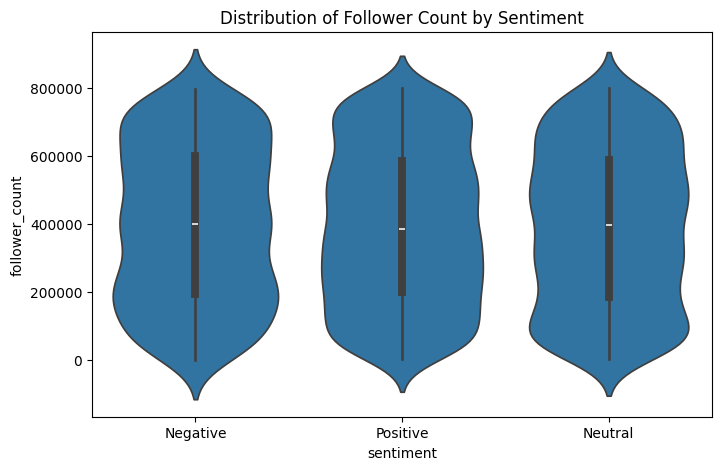

In [ ]:
# Violin: followers vs sentiment
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='sentiment', y='follower_count')
plt.title("Distribution of Follower Count by Sentiment")
plt.show()

**Insight**

The violin plot shows a nearly identical distribution of follower counts across Negative, Positive, and Neutral sentiments, suggesting that a creator's audience size does not significantly influence the sentiment of the engagement they receive

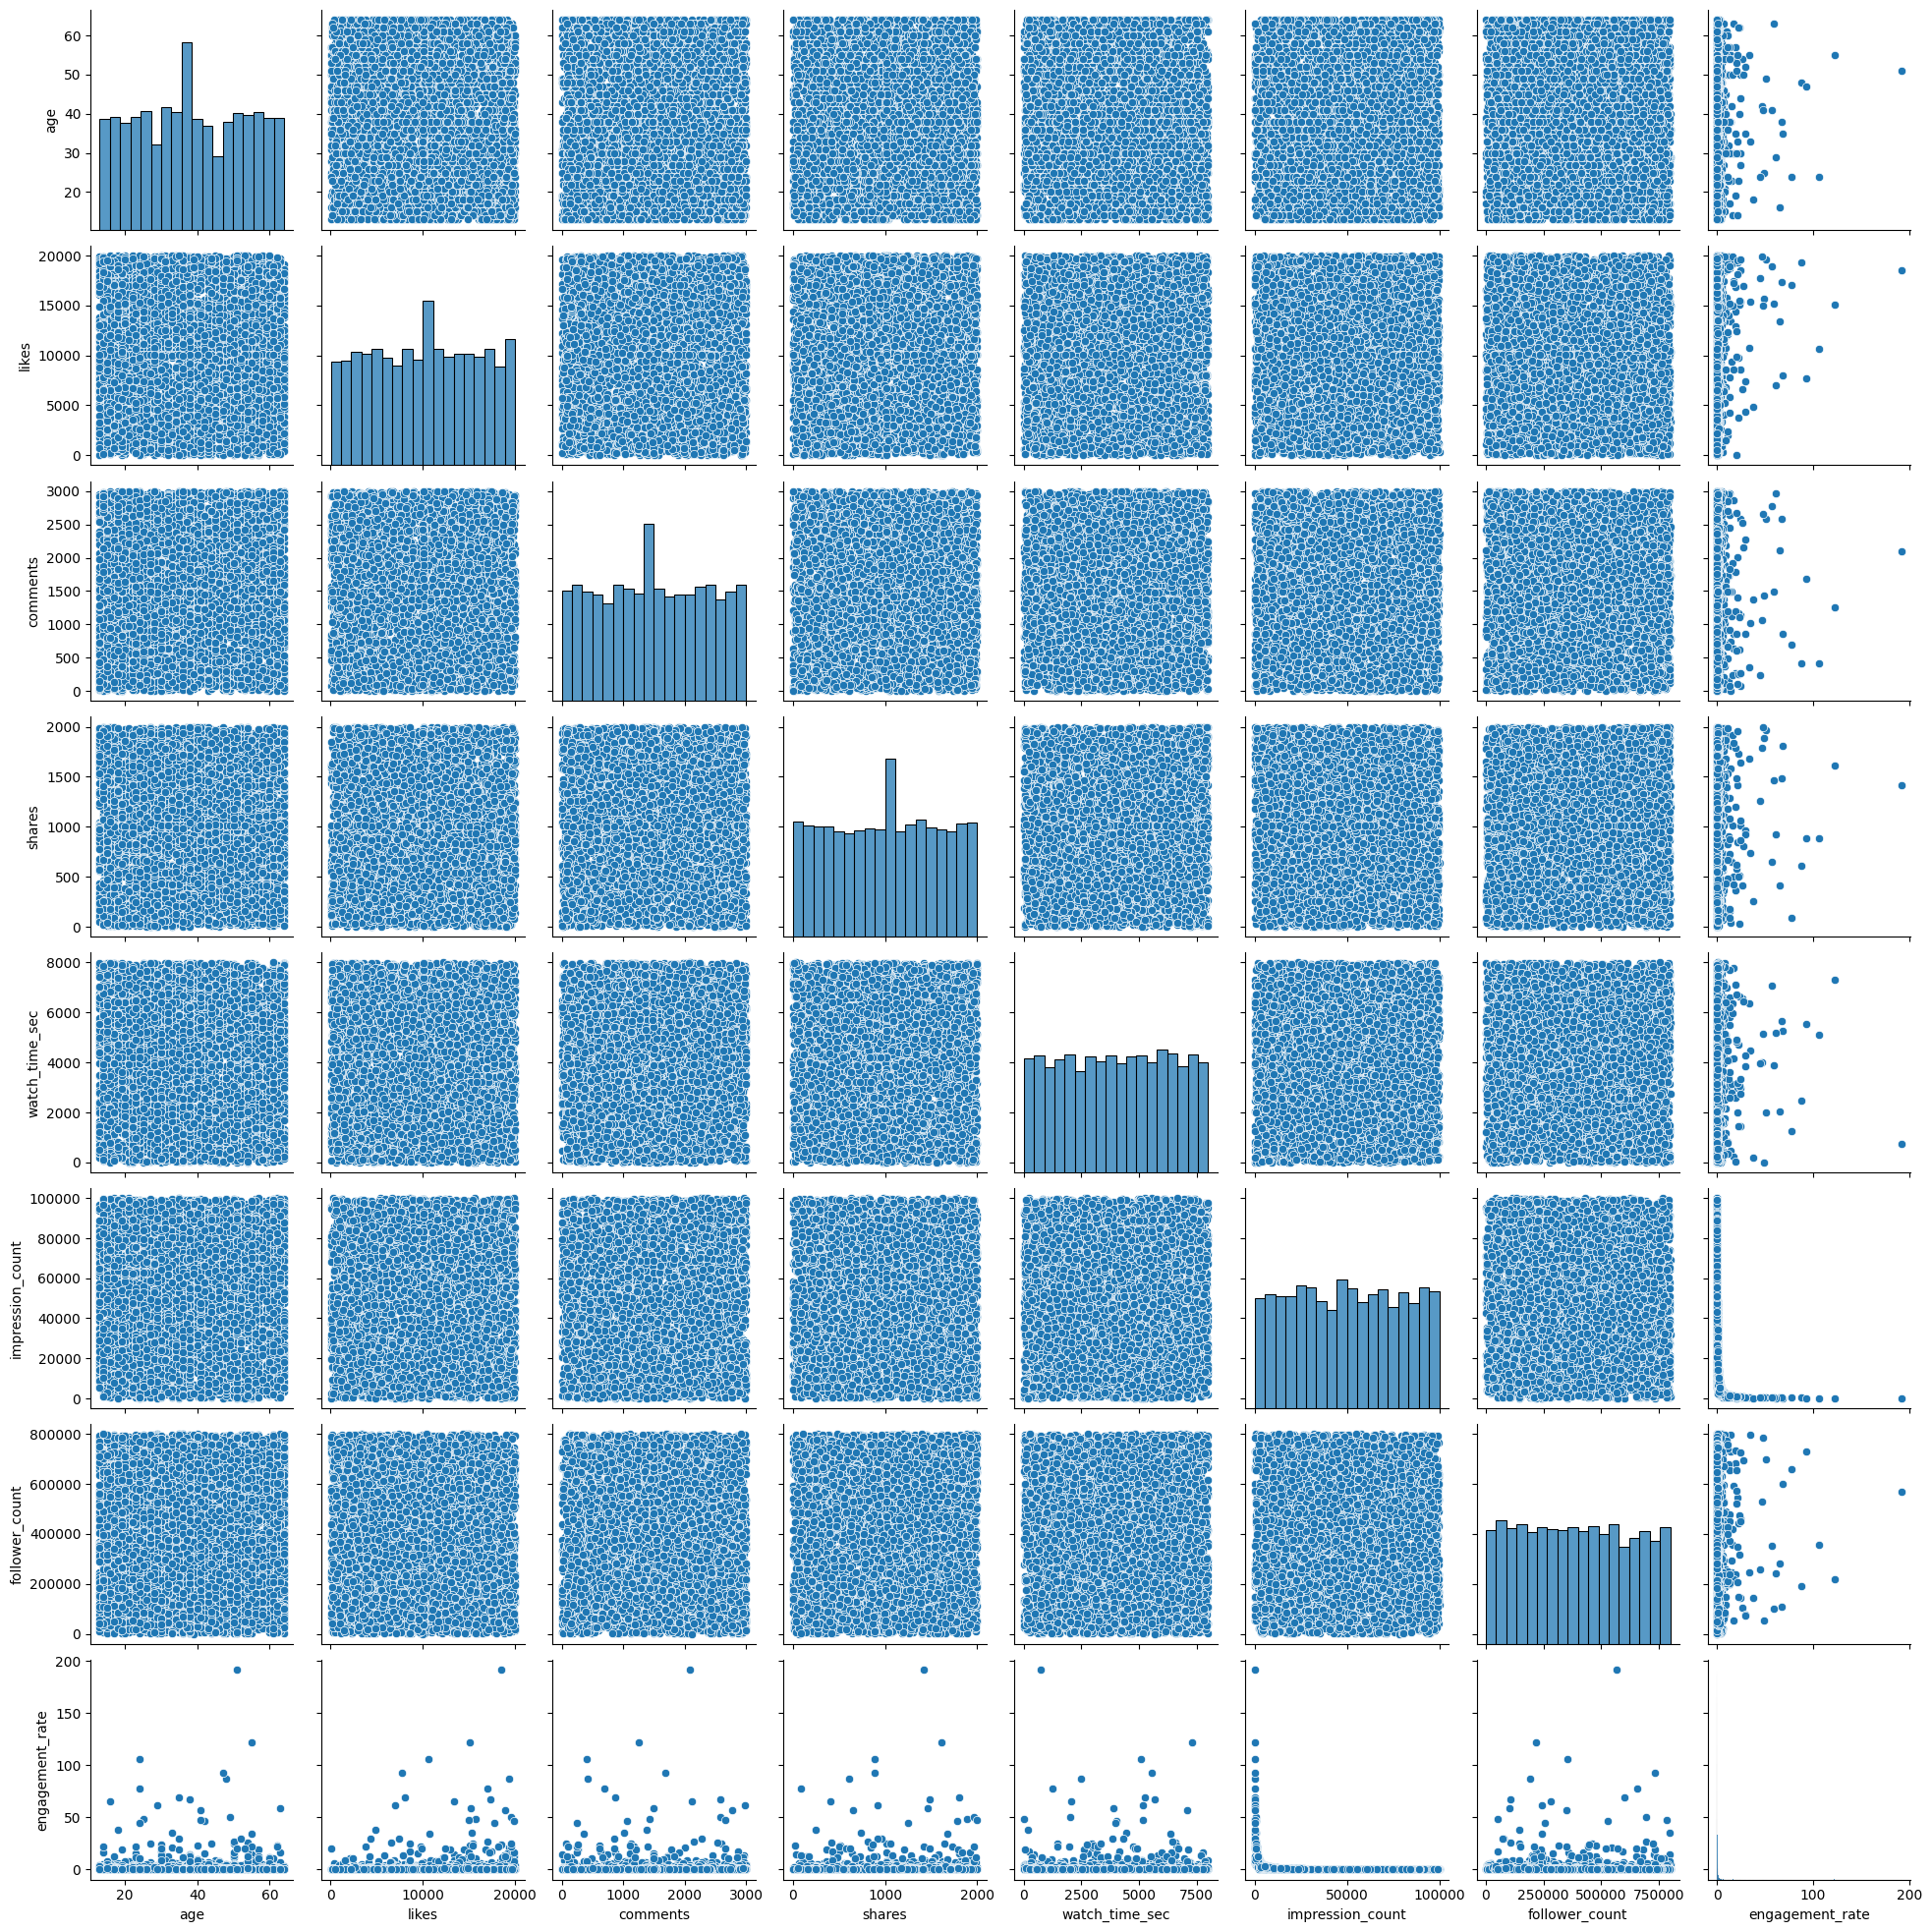

In [ ]:
# Pair plot: numeric features
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec',
                'impression_count', 'follower_count', 'engagement_rate']

sns.pairplot(df[numeric_cols].dropna())
plt.show()

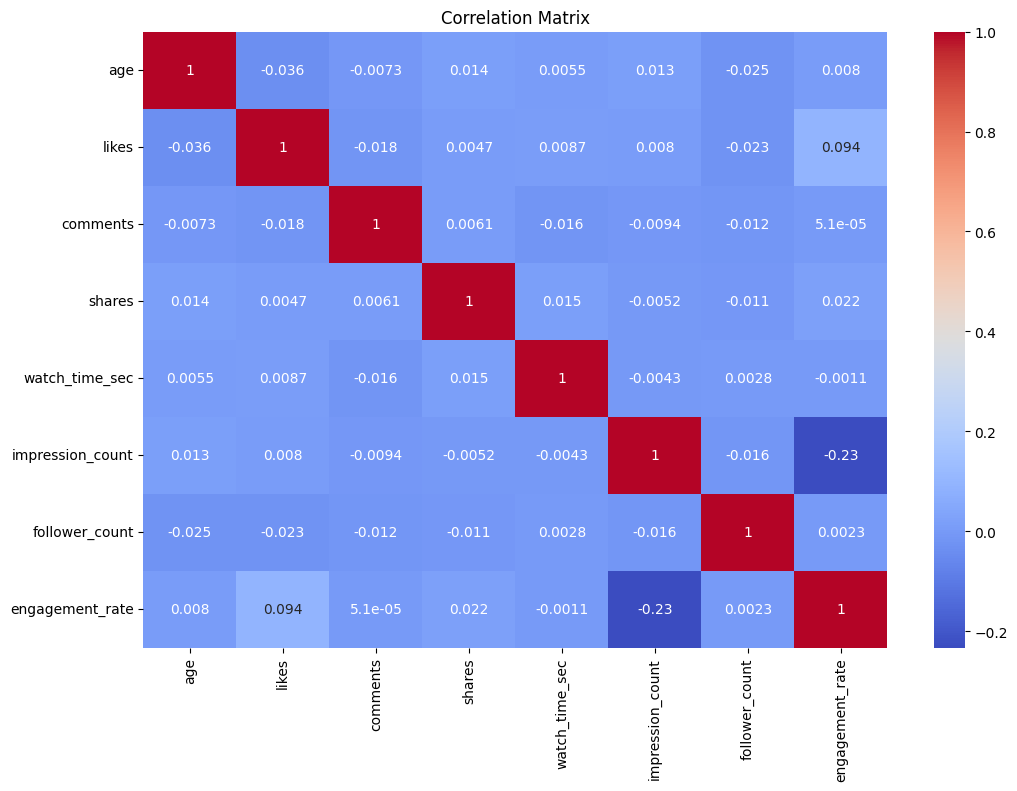

In [ ]:
# Heatmap: correlation matrix
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

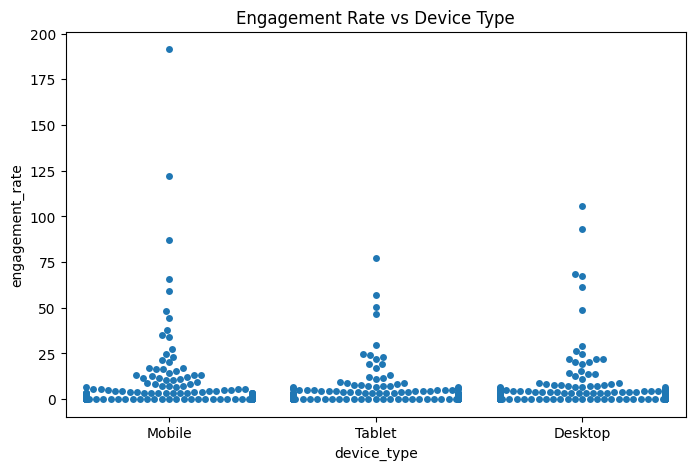

In [ ]:
# Swarm plot: engagement vs device
plt.figure(figsize=(8,5))
sns.swarmplot(data=df, x='device_type', y='engagement_rate')
plt.title("Engagement Rate vs Device Type")
plt.show()

In [ ]:
# Plotly (Interactive)
# line char
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

fig = px.line(df, x='posted_at', y='likes', title="Interactive Likes Over Time",
              markers=True)
fig.show()

In [ ]:
# bar chart
agg = df.groupby('post_category')['likes'].mean().reset_index()
fig = px.bar(agg, x='post_category', y='likes', title="Avg Likes by Category (Interactive)")
fig.show()

In [ ]:
# bubble chart
fig = px.scatter(df, x='likes', y='comments',
                 color='post_category',
                 size='follower_count',
                 hover_data=['post_type', 'device_type'],
                 title="Likes vs Comments (Interactive)")
fig.show()

In [ ]:
# scatter chart
fig = px.scatter(df, x='likes', y='comments',
                 size='engagement_rate',
                 color='device_type',
                 hover_name='post_type',
                 title="Bubble Chart: Likes, Comments & Engagement Rate")
fig.show()

**Final Insights**

**Content Performance**

**Highest engagement post types:**

Video posts have the highest avg engagement, followed by image and text posts.

**Best content category:**

Tutorials and entertainment posts receive the most likes.

**Top countries:**

USA, UK, and India show the highest average engagement.


**User Trends**

**Age effect**:

Users 25–35 show highest engagement.

**Verified accounts:**

Verified users get higher engagement than non-verified.

**Behavioral Insights**

**Best time for impressions:**

Posts between 6–9 PM get highest impressions.

**Device impact:**

Mobile users spend more watch time than desktop users.

**Sentiment Analysis**

**Best-performing sentiment:**

Positive sentiment posts have highest engagement.

**Negative/neutral posts:**

Negative posts have lower median engagement, neutral posts are moderate.